In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  StandardScaler


# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Evaluasi
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve

In [2]:
df = pd.read_csv(r'D:\Kitab Suci\Fixxxx belajar\Machine Learning\Dataset\heart (1).csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


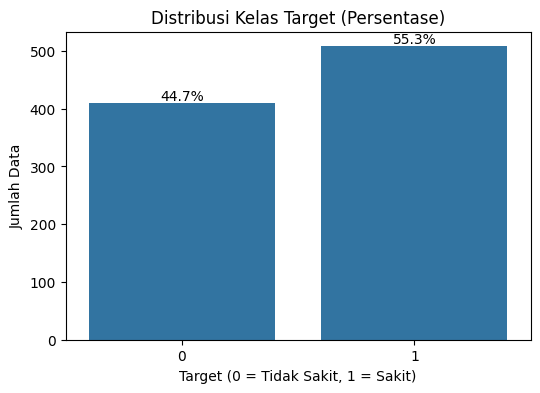

In [7]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='HeartDisease', data=df)

total = len(df)
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom'
    )

plt.title("Distribusi Kelas Target (Persentase)")
plt.xlabel("Target (0 = Tidak Sakit, 1 = Sakit)")
plt.ylabel("Jumlah Data")
plt.show()

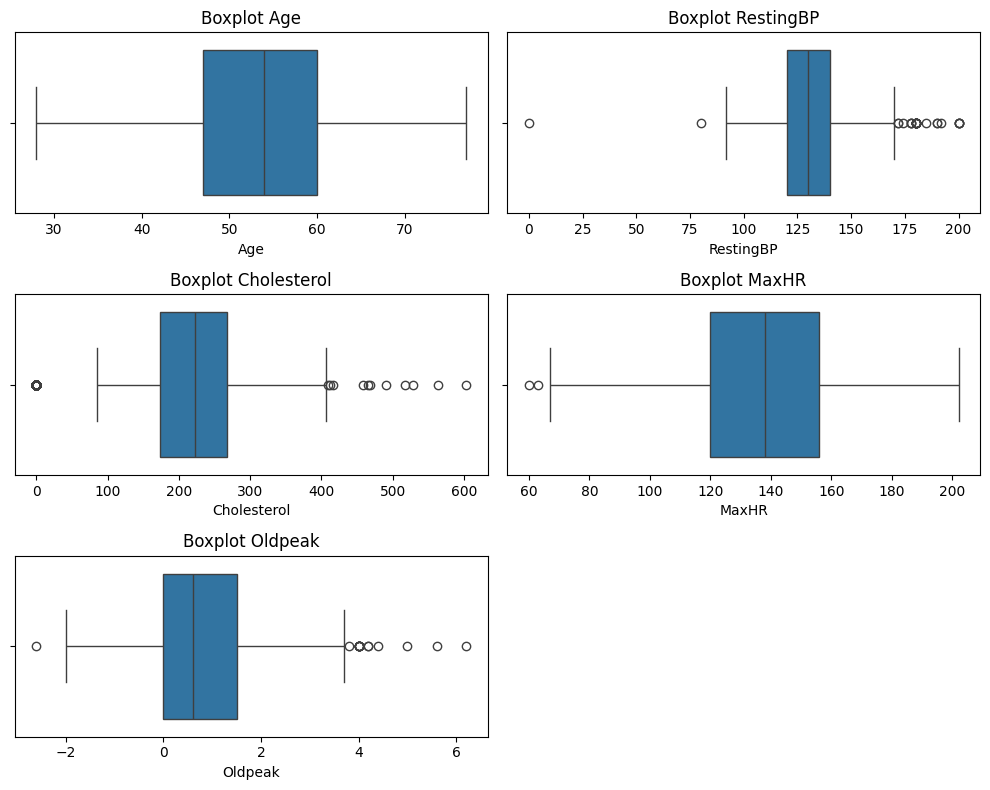

In [8]:
# Cek outlier
cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# buat ukuran figure per grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))  
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot {col}')

for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [9]:
# Kolesterol dan RestingBP = 0 tidak logis secara medis, ganti dengan median
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df.fillna(df.median(numeric_only=True), inplace=True)

In [10]:
# Binary encoding
df['Sex'] = df['Sex'].map({'M': 1, 'F': 0})
df['ExerciseAngina'] = df['ExerciseAngina'].map({'Y': 1, 'N': 0})

# Ordinal encoding
df['ST_Slope'] = df['ST_Slope'].map({'Down': 0, 'Flat': 1, 'Up': 2})

# One-hot encoding
df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG'], drop_first=True, dtype=int)

df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
0,40,1,140.0,289.0,0,172,0,0.0,2,0,1,0,0,1,0
1,49,0,160.0,180.0,0,156,0,1.0,1,1,0,1,0,1,0
2,37,1,130.0,283.0,0,98,0,0.0,2,0,1,0,0,0,1
3,48,0,138.0,214.0,0,108,1,1.5,1,1,0,0,0,1,0
4,54,1,150.0,195.0,0,122,0,0.0,2,0,0,1,0,1,0


In [11]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']


In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  

=== Logistic Regression Evaluation ===
Accuracy: 0.8695652173913043

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85        82
           1       0.86      0.91      0.89       102

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184



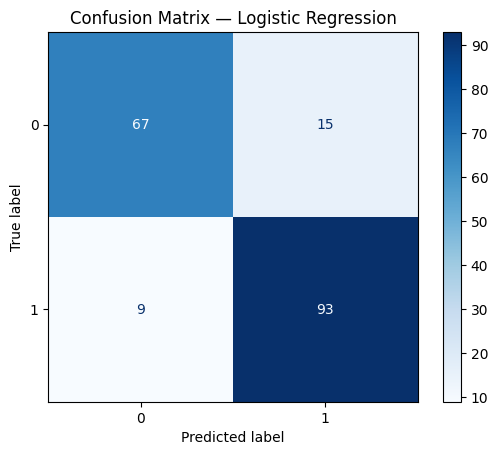

In [13]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, Y_train)

y_pred_log = log_model.predict(X_test_scaled)
print("=== Logistic Regression Evaluation ===")
print("Accuracy:", accuracy_score(Y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_log))

# Confusion Matrix
cm = confusion_matrix(Y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=log_model.classes_
)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression")
plt.show()


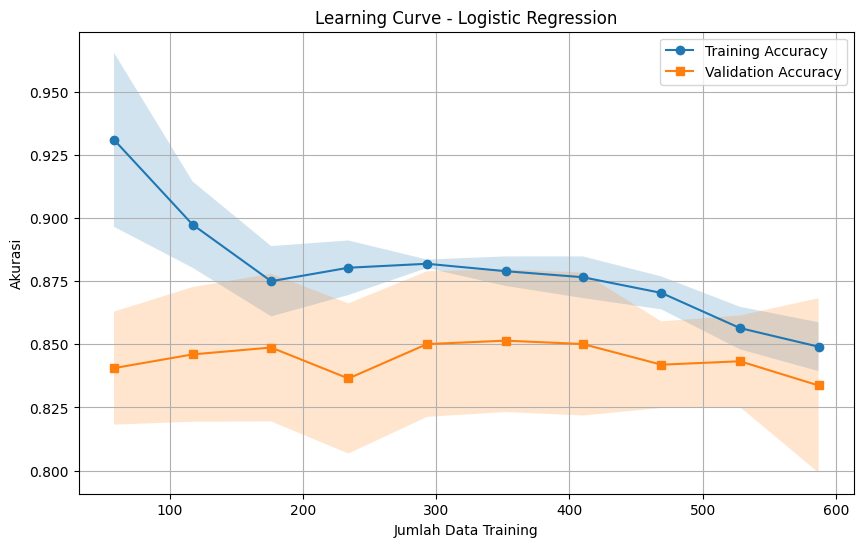

In [14]:
train_sizes, train_scores, val_scores = learning_curve(
    log_model,
    X_train_scaled,
    Y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve - Logistic Regression")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend()
plt.show()

=== KNN Evaluation ===
Accuracy: 0.8478260869565217

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        82
           1       0.85      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184



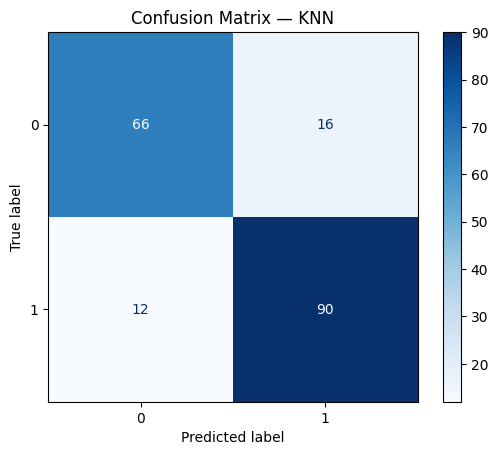

In [15]:
# KNN
knn_model = KNeighborsClassifier(
    n_neighbors=13,
    metric='minkowski'
)

knn_model.fit(X_train_scaled, Y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("=== KNN Evaluation ===")
print("Accuracy:", accuracy_score(Y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_knn))

# Confusion Matrix
cm_knn = confusion_matrix(Y_test, y_pred_knn)

disp_knn = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=knn_model.classes_
)
disp_knn.plot(cmap='Blues')
plt.title("Confusion Matrix — KNN")
plt.show()

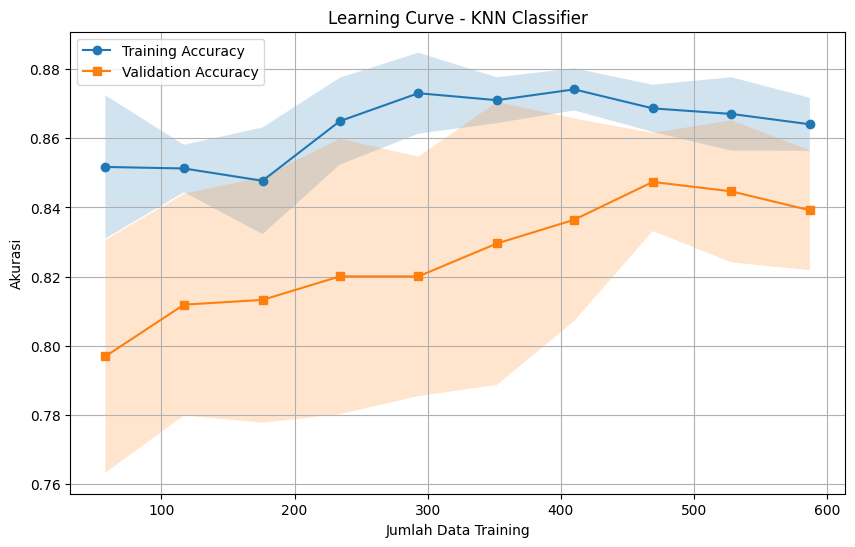

In [16]:
train_sizes, train_scores, val_scores = learning_curve(
    knn_model,
    X_train_scaled,  
    Y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Hitung mean dan std
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve - KNN Classifier")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend()
plt.show()

=== Decision Tree Evaluation ===
Accuracy: 0.7771739130434783

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.76      0.75        82
           1       0.80      0.79      0.80       102

    accuracy                           0.78       184
   macro avg       0.77      0.78      0.77       184
weighted avg       0.78      0.78      0.78       184



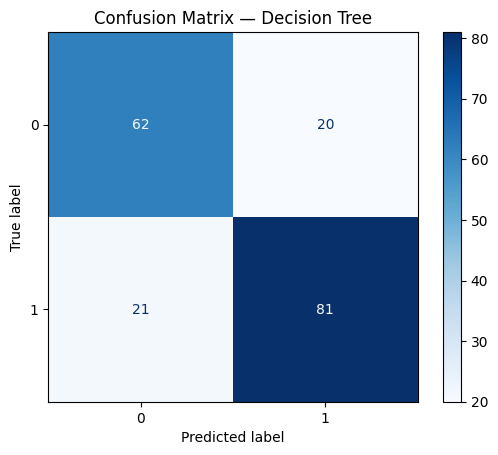

In [17]:
# Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train, Y_train)


y_pred_dt = dt_model.predict(X_test)

print("=== Decision Tree Evaluation ===")
print("Accuracy:", accuracy_score(Y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_dt))

# Visualisasi Confusion Matrix
cm = confusion_matrix(Y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dt_model.classes_
)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Decision Tree")
plt.show()

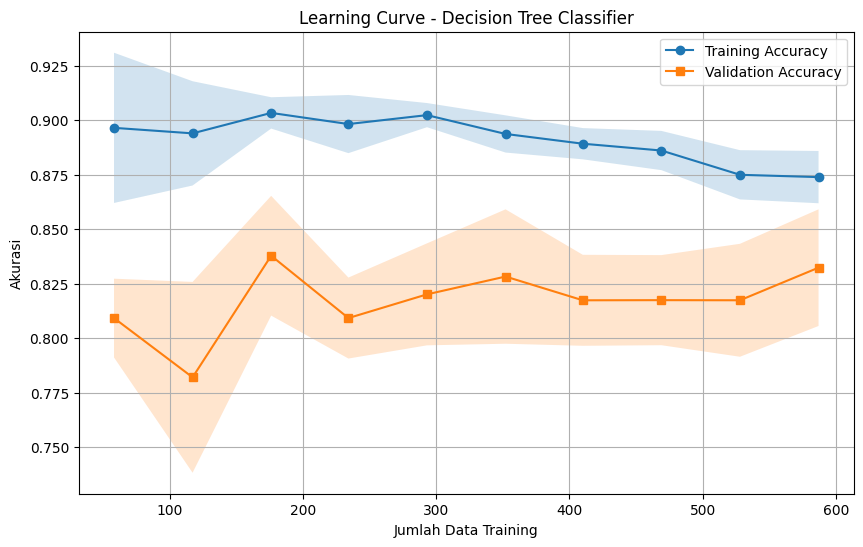

In [18]:
train_sizes, train_scores, val_scores = learning_curve(
    dt_model,
    X_train,
    Y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve - Decision Tree Classifier")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend()
plt.show()

=== Random Forest Evaluation ===
Accuracy: 0.8586956521739131

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        82
           1       0.87      0.87      0.87       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



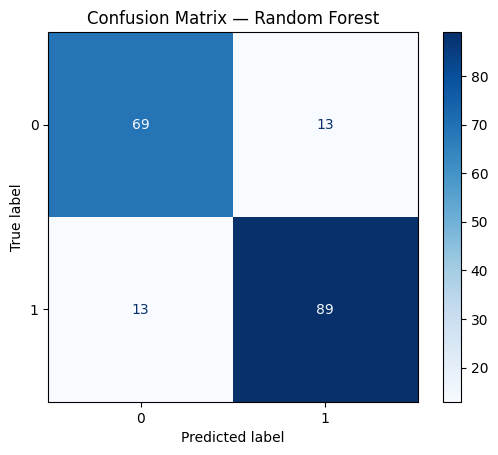

In [19]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    min_samples_split=12,
    min_samples_leaf=8,
    random_state=42
)

rf_model.fit(X_train, Y_train)


y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest Evaluation ===")
print("Accuracy:", accuracy_score(Y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_rf))

# Visualisasi Confusion Matrix
cm = confusion_matrix(Y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Random Forest")
plt.show()

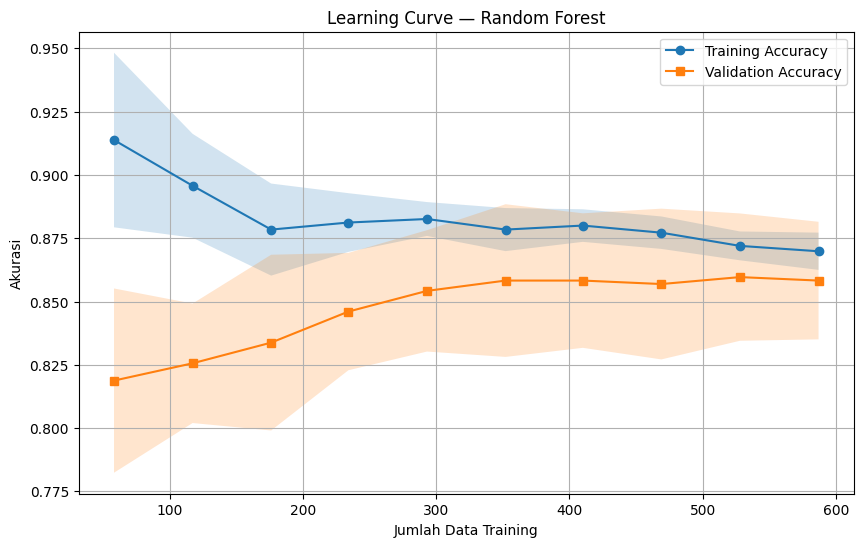

In [20]:
train_sizes, train_scores, val_scores = learning_curve(
    rf_model,
    X_train,
    Y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve — Random Forest")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend()
plt.show()

=== XGBoost Evaluation ===
Accuracy: 0.875

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86        82
           1       0.88      0.89      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184



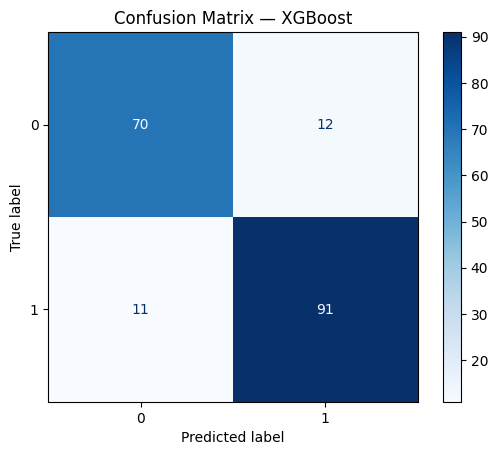

In [21]:
# xgboost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.5,
    min_child_weight=5,
    random_state=42
)
xgb_model.fit(X_train, Y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("=== XGBoost Evaluation ===")
print("Accuracy:", accuracy_score(Y_test, y_pred_xgb))
print("\nClassification Report:")   
print(classification_report(Y_test, y_pred_xgb))

# Visualisasi Confusion Matrix
cm = confusion_matrix(Y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=xgb_model.classes_
)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — XGBoost")
plt.show()

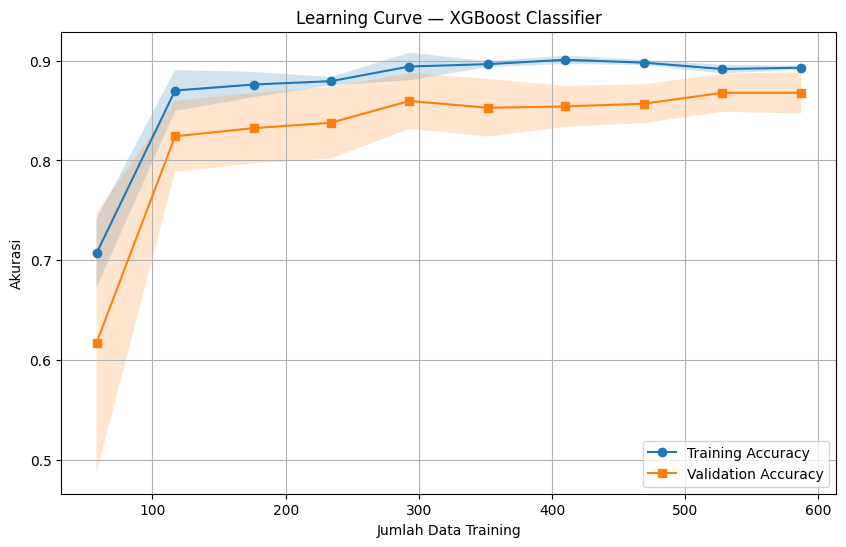

In [22]:
train_sizes, train_scores, val_scores = learning_curve(
    xgb_model,
    X_train,
    Y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve — XGBoost Classifier")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend()
plt.show()

=== SVM Evaluation ===
Accuracy: 0.842391304347826

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.77      0.81        82
           1       0.83      0.90      0.86       102

    accuracy                           0.84       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



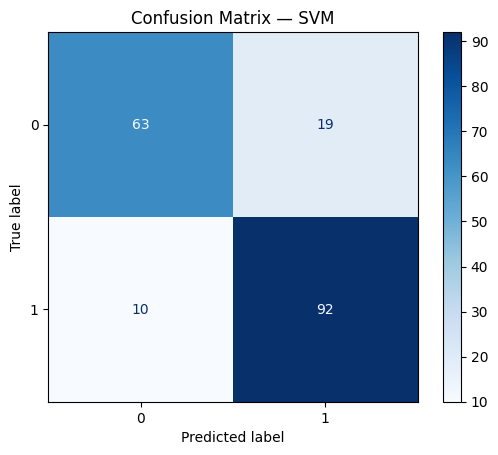

In [23]:
# SVM 
svm_model = SVC(
    kernel='rbf',        
    C=1.0,               
    gamma='scale',      
    random_state=42
)

svm_model.fit(X_train_scaled, Y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print("=== SVM Evaluation ===")
print("Accuracy:", accuracy_score(Y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_svm))

# Confusion Matrix
cm_svm = confusion_matrix(Y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=svm_model.classes_
)
disp_svm.plot(cmap='Blues')
plt.title("Confusion Matrix — SVM")
plt.show()

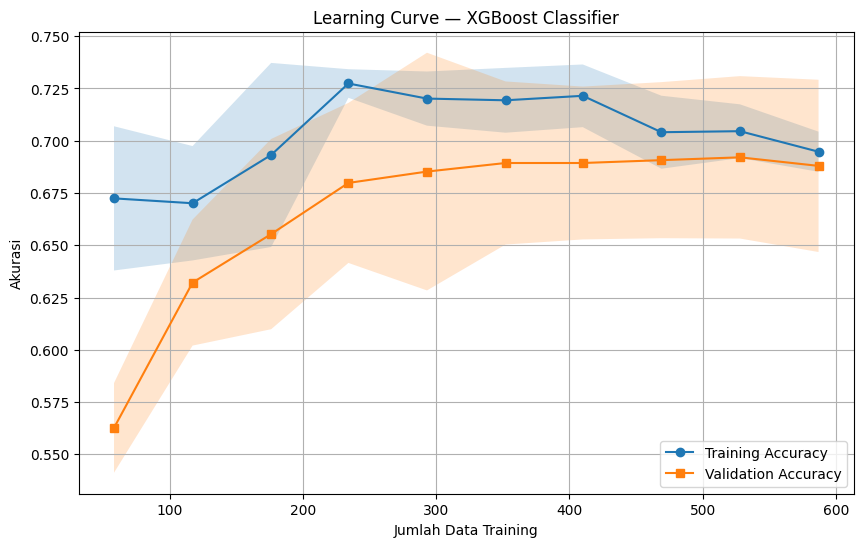

In [24]:
train_sizes, train_scores, val_scores = learning_curve(
    svm_model,
    X_train,
    Y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve — XGBoost Classifier")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend()
plt.show()

In [25]:
def evaluate_model(model, X_test, Y_test):
    y_pred = model.predict(X_test)
    return {
        "Accuracy" : accuracy_score(Y_test, y_pred),
        "Precision": precision_score(Y_test, y_pred, average='weighted'),  # ganti binary → weighted
        "Recall"   : recall_score(Y_test, y_pred, average='weighted'),
        "F1 Score" : f1_score(Y_test, y_pred, average='weighted'),
    }

In [26]:
results = []

# Logistic Regression
results.append({
    "Model": "Logistic Regression",
    **evaluate_model(log_model, X_test_scaled, Y_test)
})

# KNN
results.append({
    "Model": "KNN",
    **evaluate_model(knn_model, X_test_scaled, Y_test)
})

# Decision Tree
results.append({
    "Model": "Decision Tree",
    **evaluate_model(dt_model, X_test, Y_test)
})

# Random Forest
results.append({
    "Model": "Random Forest",
    **evaluate_model(rf_model, X_test, Y_test)
})

# XGBoost
results.append({
    "Model": "XGBoost",
    **evaluate_model(xgb_model, X_test, Y_test)
})

# SVM
results.append({
    "Model": "SVM",
    **evaluate_model(svm_model, X_test_scaled, Y_test)
})

In [27]:
comparison_df = pd.DataFrame(results)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.869565,0.870233,0.869565,0.868952
1,KNN,0.847826,0.847763,0.847826,0.847387
2,Decision Tree,0.777174,0.777473,0.777174,0.777300
3,Random Forest,0.858696,0.858696,0.858696,0.858696
4,XGBoost,0.875000,0.874895,0.875000,0.874921
5,SVM,0.842391,0.844063,0.842391,0.841145


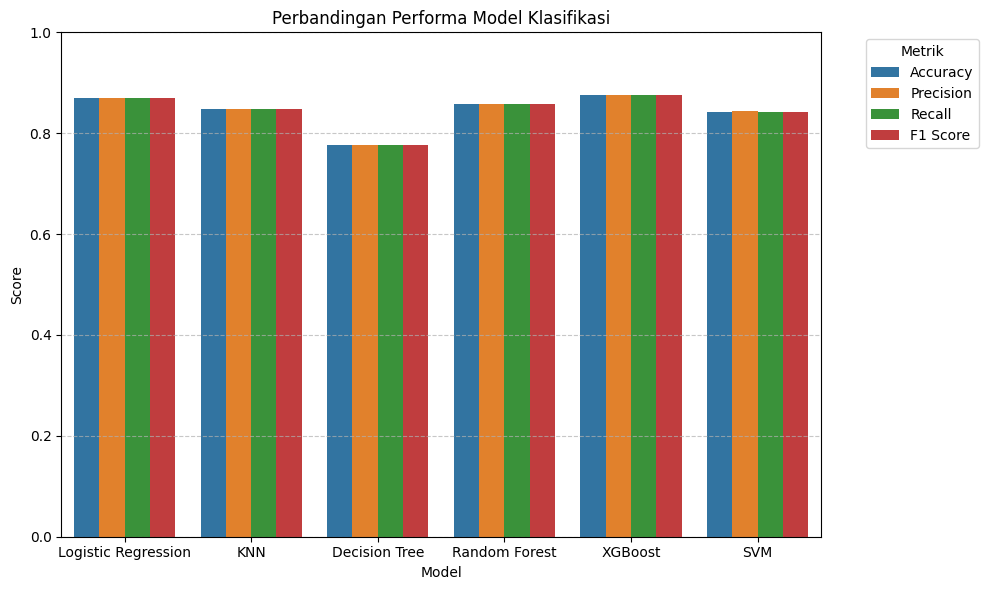

In [28]:
df_melt = comparison_df.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_melt,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title("Perbandingan Performa Model Klasifikasi")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.legend(title="Metrik", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()